<a href="https://colab.research.google.com/github/noobylub/Computational-Linguistic/blob/master/Corpus_Linguistics_2026_lecture_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Corpus Linguistics, Week 6**

We will measure time, and very briefly look at some basics about xml.

**Part 1**: Time library

In [1]:
import time

In [2]:
# Get the current time (seconds since 1 January 1970)

time.time()

1773145597.3945043

In [3]:
# We already used the time library in Week 2 to pause for some time when repeatedly calling a server

time.sleep(1)     # "sleep" for on second

In [ ]:
# Time your script

start = time.time()

# ... process all your corpus files ...
time.sleep(1.3)
# ... end of the active part of your script ...

ellapsed_time = time.time() - start
print(f"Finished in {ellapsed_time:.1f} seconds")
# float, round to . 0 digits


Finished in 1.3 seconds


In [ ]:
start_time = time.time()
time.sleep(2)
elapsed = time.time() - start_time


# divmod(a, b) returns two values: (a // b, a % b)
# the quotient (how many times b fits into a)
# the remainder (what's left over)
#
# divmod(elapsed, 3600) divides by 3600 because there are 3600 seconds in an hour
# hours = how many complete hours
# remainder = leftover seconds after removing full hours
hours, remainder = divmod(elapsed, 3600)

# divmod(remainder, 60) divides by 60 because there are 60 seconds in a minute
# minutes = how many complete minutes in the remainder
# seconds = leftover seconds after removing full minutes
minutes, seconds = divmod(remainder, 60)

print(f"Processing took {int(hours):02d}:{int(minutes):02d}:{seconds:05.2f}")

# Format specifiers inside the f-string:
#
# int(hours):02d
# int(hours) converts float to integer (e.g., 1.0 → 1)
# 02d means: display as decimal integer (d), at least 2 digits wide (2), pad with zeros (0)
# e.g., 1 → "01", 12 → "12"
#
# int(minutes):02d
# same as above: two-digit integer with leading zero
# e.g., 5 → "05", 45 → "45"
#
# seconds:05.2f
#   - f means: display as float (decimal number)
#   - .2 means: 2 decimal places
#   - 05 means: total width of 5 characters, pad with zeros
#   - e.g., 2.5 → "02.50", 12.3 → "12.30"

print(f"Processing took {int(hours):d} hours, {int(minutes):d} minutes, and {int(seconds):d} seconds.")

Processing took 00:00:02.00
Processing took 0 hours, 0 minutes, and 2 seconds.


In [ ]:
# Revision: We also used datetime to get a date, e.g., when scraping a text from the web

# To record the date of scraping
from datetime import datetime

# Using strftime() to format the date as dd/mm/yyyy
current_date = datetime.now().strftime('%d %B %Y')

print (current_date)

# Some options:
# datetime.now().strftime('%d/%m/%Y')        # "08/02/2026"     (day/month/year)
# datetime.now().strftime('%Y-%m-%d')        # "2026-02-08"     (ISO format, good for sorting)
# datetime.now().strftime('%d %b %Y')        # "08 Feb 2026"    (abbreviated month)
# datetime.now().strftime('%A, %d %B %Y')    # "Sunday, 08 February 2026"
# datetime.now().strftime('%Y-%m-%d %H:%M')  # "2026-02-08 14:35" (with time)
# datetime.now().strftime('%d/%m/%Y %H:%M:%S')  # "08/02/2026 14:35:22"

10 March 2026




---



**Part 2**: Constituency parsing with the Stanford Parser

In [4]:
!pip install stanza

import stanza


# Create a Stanza NLP pipeline for English
#
# stanza.Pipeline() initializes a processing pipeline
#
# Arguments:
#   'en'          - language code for English (other options: 'de', 'fr', 'zh', etc.)
#
#   processors=   - which NLP tasks to include, comma-separated string:
#       'constituency'  - constituency parsing (phrase structure trees)
#
# Other available processors you could add:
#       'lemma'         - lemmatisation
#       'ner'           - named entity recognition
#       'depparse'      - dependency parsing
#       'sentiment'     - sentiment analysis
#       'pos'           - part-of-speech tagging (required for constituency parsing)
#       'constituency'  - constituency parsing (phrase structure trees)
#       'tokenize'      - split text into sentences and words
#
# Example with more processors:
#   nlp = stanza.Pipeline('en', processors='tokenize,pos,lemma,ner,depparse')
# Note: Constituency also requires pos tags and sentence tokens, so those go together
# Note: More processors = slower processing, so only include what you need


stanza.download('en')
# tokenize, pos, constituency must be used together
nlp = stanza.Pipeline('en', processors='tokenize,pos,constituency')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.2/337.2 kB 19.0 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor    | Package             |
--------------------------------------
| tokenize     | combined            |
| mwt          | combined            |
| pos          | combined_charlm     |
| constituency | ptb3-revised_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: constituency
INFO:stanza:Done loading processors!


In [12]:
# Parse a document

text = "The cat sat on the mat. It was not happy."
text = "The complex houses married and single soldiers and their families."
processed_text = nlp(text)




In [6]:
# access every individual sentence with .sentences (like .sents in spacy), a list of all sentence tokens
for sentence in processed_text.sentences:
    print(sentence.constituency)

(ROOT (S (NP (DT The) (NN cat)) (VP (VBD sat) (PP (IN on) (NP (DT the) (NN mat)))) (. .)))
(ROOT (S (NP (PRP It)) (VP (VBD was) (RB not) (ADJP (JJ happy))) (. .)))


**Exercise**: Copy a paragraph off an internet website you like and constituency-parse it. Then save your output. Give your file the extension `.psd` (for parsed)

In [9]:
# Parse a paragraph, save file

my_para = "The complex houses married and single soldiers and their families."


In [10]:
# svgling (Scalable Vector Graphics + linguistics) is a Python library specifically designed for drawing syntax trees
# draw_tree is a function from this library that converts tree structures into SVG graphics
!pip install svgling
from svgling import draw_tree

# We'll also need the tree-related import from nltk
# Tree from nltk converts benepar ("(S (NP (DT The)...)") into a tree data structure
# This will then be plotted nicely with svgling
from nltk import Tree

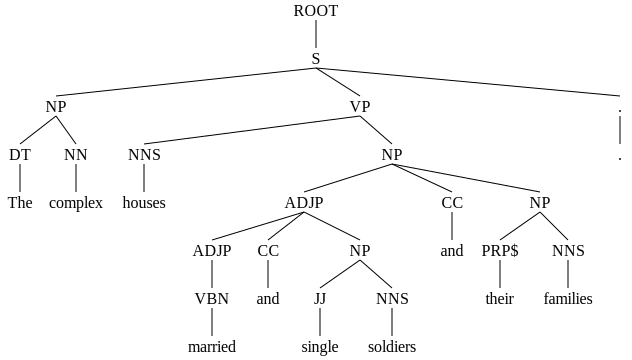

In [13]:
for sent in processed_text.sentences:

    # Convert Stanza tree to string, then to NLTK Tree
    tree_string = str(sent.constituency)
    nltktree = Tree.fromstring(tree_string)

    # Create and display the SVG
    svgtree = draw_tree(nltktree)
    display(svgtree)

**Exercise**: Parse a complex English sentence of your choice with the Berkeley Neural Parser. Does the result make sense?

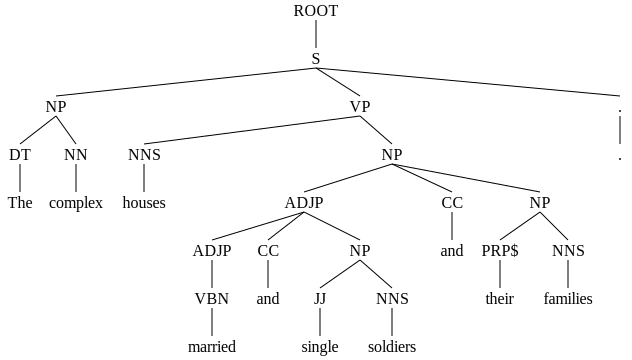

In [14]:
#Add your sentence here
my_sentence = "The complex houses married and single soldiers and their families."
my_sentence_processed = nlp(my_sentence)

# Convert Stanza tree to string, then to NLTK Tree
tree_string = str(my_sentence_processed.sentences[0].constituency)
nltktree = Tree.fromstring(tree_string)

# Create and display the SVG
svgtree = draw_tree(nltktree)
display(svgtree)



Now consider the parses of the following three sentences. For each, explain why the output is problematic.

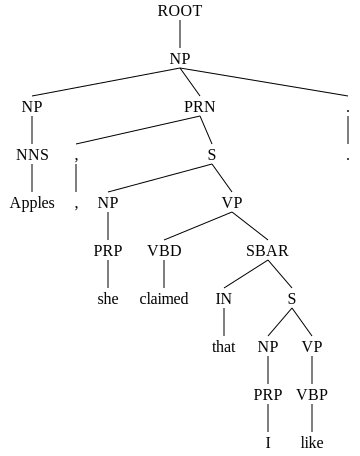

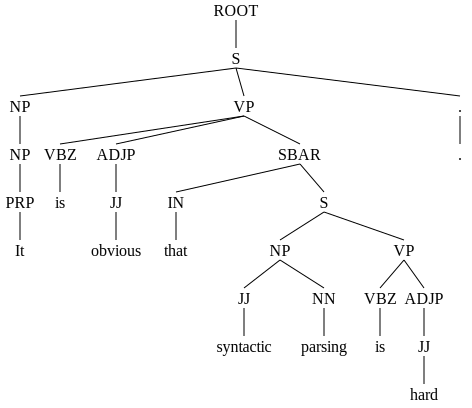

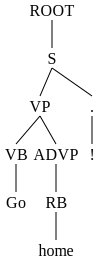

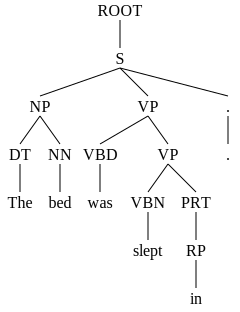

In [15]:
#Add your sentence here
difficult_sentences = "Apples, she claimed that I like. It is obvious that syntactic parsing is hard. Go home! The bed was slept in."
difficult_sentences_processed = nlp(difficult_sentences)

for sent in difficult_sentences_processed.sentences:
    tree_string = str(sent.constituency)
    nltktree = Tree.fromstring(tree_string)
    # Create and display the SVG
    svg = draw_tree(nltktree)
    display(svg)

**Part 3**: Reading XML in python

XML<br>
Python has a built-in module to work with XML files. Go to https://docs.python.org/3.14/genindex.html, click on "X" (for XML).<br>
For corpus linguistics, you'll likely be most interested in `xml.etree.ElementTree`, the most commonly used and a user-friendly approach for parsing XML in Python.

**A) Learning about ElementTree**

In [16]:
import xml.etree.ElementTree as ET


In [22]:
# Create an example XML document as a string.
# Save the XML string in a variable
# I use ''' because " appears within the XML string. ''' allows you to write a string across several lines.

xml_string = '''<doc>
    <sentence id="1">
        <word pos="DET" lemma="the">The</word>
        <word pos="NOUN" lemma="cat">cat</word>
        <word pos="VERB" lemma="sit">sits</word>
        <word pos="ADP" lemma="on">on</word>
        <word pos="DET" lemma="the">the</word>
        <word pos="NOUN" lemma="mat">mat</word>
    </sentence>
    <sentence id="2">
        <word pos="PRON" lemma="it">It</word>
        <word pos="VERB" lemma="be">is</word>
        <word pos="ADV" lemma="categorically">categorically</word>
        <word pos="ADJ" lemma="happy">happy</word>
    </sentence>
</doc>'''

In [23]:
# Parse the string as XML
# For this use the function fromstring()
tree = ET.fromstring(xml_string)

# Now 'tree' contains your XML structure and you can work with it

In [19]:
# The first useful function on XML structures is findall()
# It takes a so-called XPath expression as input and returns all matching elements

# Find all word elements
words = tree.findall('.//word')
print(f"Found {len(words)} words")  # Should find 10 words

Found 10 words


# Quick intro to XPath<br>
The syntax of XPath resembles a directory structure: forward slashes ("/") are used to traverse through nodes.<br>

* The dot `.` will start searching from the current node. It's a "relative path." Start your XPath with a dot.
* One backward slash `/` means direct children, one step down.
* Two backward slashes `//` mean any depth, look into all daughter nodes.

(Note that not all functionality of XPath is available in Element Tree's functions)

**Exercise**:<br>
How many words will `words = tree.findall('./word')` retrieve in our XML structure? Why?



```
words = tree.findall('./word')
print(f"Found {len(words)} words")  # How many words and why?
```



In [25]:
# The .text attribute will return the content of an element
# The .tag attribute will return the element name (you could also say: label, span or tag) of the element

print("Text:")
words = tree.findall('.//word')
for word in words:
    print(word.text)

print("\nTags:")
all_elements = tree.findall('.//')
for elements in all_elements:
    print(elements.tag)

Text:
The
cat
sits
on
the
mat
It
is
categorically
happy

Tags:
sentence
word
word
word
word
word
word
sentence
word
word
word
word


In [24]:
# Another useful function on XML structures is find()
# It takes a XPath expression as input and returns the first matching element

# Find the FIRST word element only
words = tree.find('.//word')
print(f"The first matching 'word' element in this XML document is: {words.text}")

The first matching 'word' element in this XML document is: The


In [ ]:
# You can use the [@...] notation after the tag / label of an element to find its attributes.
# That means, in XPath, [] is used for conditions on elements in terms of attributes
# @ means "attribute"
# So [@lemma="cat"] means "... where the lemma attribute equals 'cat'"
# To find all words where lemma="cat"

cat_words = tree.findall('.//word[@lemma="cat"]')

# Print what we found
for word in cat_words:
   print(f"Found word: {word.text}")

In [ ]:
# The function get() takes an attribute (as a string, the element after '@') of an element and returns its value (as a string)

words = tree.findall('.//word')
# get the pos tags for every word
for word in words:
  POS = word.get('pos')
  print(POS)

In [ ]:
# startswith
# ElementTree's XPath doesn't support regular expressions like lemma="cat.*"
# However, you CAN find all word elements starting with a string using startswith('string')
# You can use startswith on both content retrieved with .text and attributes retrieved with .get()

print("Here are all lemmas starting with 'cat...':")
all_words = tree.findall('.//word')
for word in all_words:
  lemma = word.get('lemma')
  if lemma.startswith('cat'):
    print(lemma)

print("\nHere are all words starting with 'i':")
for word in all_words:
  text = word.text.lower() # use lower() on text to get lower case
  if text.startswith('i'):
    print(text)

In [ ]:
# The function .iter() walks through ALL elements of the tree, in order

print("Visiting every node of the tree.")
for element in tree.iter():
  print(f'The content of the element is: {element.text}')

**B) Using Element Tree with a real corpus**

In [ ]:
# Upload some XML-parsed files (from the BNC corpus, XML version)

from google.colab import files

# Create a list to store all uploaded files
uploaded_files = files.upload()

In [ ]:
# ElementTree's parse() will open a file and return its content as an element tree / XML structure
# You can loop through all the XML files in your corpus, and parse them as XML structures one after another

for file in uploaded_files:
  print(f"Now turning file {file} into an XML structure")
  tree=ET.parse(file)
  # You'd the process each file here
  # ...

* For every example, store the file ID it comes from (e.g. A0A, B22 etc).<br>
* The BNC XML files contain lot of meta-information at the beginning of the file.<br>
The tag `<classCode `... includes a W (written) or S (spoken) followed by a sub-genre. For every example you should store the mode (written or spoken) and genre (e.g. pub debate). The tags `<wtext>` for written and `<stext>` for spoken texts include an attribute `type` with a more general genre. Save that as well.<br>
* The files also contain an element labelled <creation>. It contains as an attribute the year of creation. For example, `<creation date="1990"> </creation>`.

In [ ]:
# Here is one approach.
# Create empty lists to store our results
# file_id will store the name of the file
file_id = []
# genre will contain the label of the general genre of the text (from stext or wtext)
genre = []
# mode should store "written" or "spoken" (I get that information from classCode)
mode = []
# sub-genre will be one of a large number of values, like pub debate (from classCode)
subgenre = []
# year will contain the year of creation of the text
year = []

for file in uploaded_files:
  tree=ET.parse(file)

  # Save the name of the file
  id = file.replace('.xml', '')
  file_id.append(id)

  # Loop to find the wtext or stext tags:
  # Try wtext first
  text_element = tree.find('.//wtext')
  if text_element is None:
      # If no wtext, try stext
      text_element = tree.find('.//stext')

  genrevalue = text_element.get('type')
  genre.append(genrevalue)

  # Find the classCode element
  classcode = tree.find('.//classCode')
  # Get the full classCode like "W newsp other: science"
  meta = classcode.text

  # Split meta information
  # meta[0] will contain the first character, W or S
  if meta[0] == "W":
    mode.append("Written")
  if meta[0] == "S":
    mode.append("Spoken")
  # meta[2:] contains everything after W/S and whitespace, add to genre
  subgenre.append(meta[2:])

  # Find the creation element and get its date attribute
  creation = tree.find('.//creation')
  # gets the value of creation's date attribute
  yearvalue = creation.get('date')
  year.append(yearvalue)


  # See what we got
print("Files:", file_id)
print("Modes:", mode)
print("Genres:", genre)
print("Sub-genres:", subgenre)
print("Years:", year)

Again, there are many options. For example, you could alternatively save the meta-information in a dictionary, then use that, as in previous lectures.

Remember the structure of the BNC XML files: you will find that `<s>` tags contain `<w>` (for words) and `<c>` (for punctuation). (Note that `<s>` can be contained within spans labeld `<div>`, `<p>`...)<br>Every word inlcudes a part of speech tag from Claws 5 (c5) and the universal tags (pos) as well as hw (for headword), which is the lemma. For example: `<w c5="VVN-AJ0" hw="soak" pos="VERB">soaked </w>`

In [ ]:
# We could find all instances of "help" as follows:
# The list help_instances keeps track of all instances of "help"
help_instances = []

for file in uploaded_files:
    tree = ET.parse(file)

    # Find all words
    words = tree.findall('.//w')  # remember w is the XML BNC's tag for word

    # For each instance, get the actual word form and its pos-tag
    for word in words:
      if word.text.lower().startswith('help'):
        actual_word = word.text
        pos_tag = word.get('c5')  #use c5 not pos because c5 is more detailed
        help_instances.append((file, actual_word, pos_tag))

# Print what we found
for file, word, pos in help_instances:
    print(f"File: {file}, Word form: {word}, POS: {pos}")

In [ ]:
# Next, we want to create KWIC concordance lines for "help" from our XML files

# this list will store our KWIC concordance line
# remember: 120 characters before, 240 characters after "help" are required
help_KWIC = []
# this list will store the form of the hit, "help", "helped", "helping" etc.
help_form = []
# this list will store the POS of each hit, noun, verb, adjective, etc.
help_pos = []


# We will keep a "buffer" for the context left of "help"
# We go through the xml structure, and record every single word
# but shorten the left context / keep the length of the left context buffer the same

max_buffer = 10  # for 60 characters left of help, 10 words might typically be found

# As before, we want to save file_id, genre, mode, sub-genre, year
# file_id will store the name of the file
file_id = []
# genre will contain the label of the general genre of the text (from stext or wtext)
genre = []
# mode should store "written" or "spoken" (from classCode)
mode = []
# sub-genre will be one of a large number of values, like pub debate (from classCode)
subgenre = []
# year will contain the year of creation of the text
year = []
# I'll also add hits (1,2,3,4), corpus (always BNC) and variety (always BrE) for the sake of completeness
hits = []
hit = 1 # for the first hit, then increment for each additional hit
corpus = []
variety = []

for file in uploaded_files:
    tree = ET.parse(file)

    # (1) meta-information

    # Get the name of the file
    id = file.replace('.xml', '')

    # Loop for the wtext or stext tags:
    # Try wtext first
    wstext_element = tree.find('.//wtext')
    if wstext_element is None:
        # If no wtext, try stext
        wstext_element = tree.find('.//stext')
    genrevalue = wstext_element.get('type')

    # Find the classCode element
    classcode = tree.find('.//classCode')
    # Get the full classCode like "W newsp other: science"
    meta = classcode.text

    # Find the creation element and get its date attribute
    creation = tree.find('.//creation')
    # gets the value of creation's date attribute
    yearvalue = creation.get('date')

    # (2) make KWIC concordance

    # the left_context will keep track of the 10 previous words
    left_context = []

    # The following parameters are for collecting context to the right of "help"
    collecting_right = False   # unless we find "help", we don't collect right context by default
    right_context = []
    current_right_context_words = 0

    # iterate through every word of the tree
    for elem in tree.iter():

      # If we're collecting right context (after "help")
      if collecting_right:   # remember, for Booleans, you can just use if and if not
                             # This is the same as if collecting_right == True
          if elem.tag in ['w', 'c']:
              right_context.append(elem.text)
              if elem.tag == 'w':  # only count words, not punctuation
                  current_right_context_words += 1
                  if current_right_context_words >= 20:  # stop after ~20 words
                      collecting_right = False  # stop collecting
                      right_KWIC = ' '.join(right_context)  # join the list into a string
                      # Create KWIC line with left, help word, and right context
                      kwic_line = f"{left_KWIC} {help_word} {right_KWIC}"
                      help_KWIC.append(kwic_line)

      # If the element is a word or punctuation, add it to the left context buffer
      if elem.tag in ['w', 'c'] and not elem.text.lower().startswith('help'):
        left_context.append(elem.text)
        # Keep buffer at max size
        if len(left_context) > max_buffer:
            left_context.pop(0)

      # Check if the current elem is a hit of the word "help"
      if elem.tag == 'w' and elem.text.lower().startswith('help'):
        # This is an instance of "help"!
        left_KWIC = ' '.join(left_context) # join turns a list into a string and places ' ' in between each element

        # Get the text of this instance of "help", store it in help_form
        help_word = elem.text
        help_form.append(help_word)
         # get the pos tag (CLAWS-5 c5, not POS)
        help_c5 = elem.get('c5')
        help_pos.append(help_c5)

        # Since we have found an instance of "help", also add an instance to all the meta-information
        file_id.append(id)
        genre.append(genrevalue)

        # meta[0] will contain the first character, W or S
        if meta[0] == "W":
          mode.append("Written")
        if meta[0] == "S":
          mode.append("Spoken")
        # meta[2] contains everything after W/S and whitespace, add to genre
        subgenre.append(meta[2:])

        year.append(yearvalue)

        corpus.append("BNC")
        variety.append("BrE")

        # add the hit (as a string) to the list hits, and increment by 1
        hits.append(str(hit))
        hit += 1


        # we have found - so start collecting the right context
        collecting_right = True
        right_context = []  # Reset right context
        current_right_context_words = 0  # Reset word counter


# print the output

output = ""
for h, kwic, f, pos, id, date, var, gen, subgen, mod, corp in zip(hits, help_KWIC, help_form, help_pos, file_id, year, variety, genre, subgenre, mode, corpus):
    output += f'{h}\t{kwic}\t{f}\t{pos}\t{id}\t{date}\t{var}\t{gen}\t{subgen}\t{mod}\t{corp}\n'
print(output)

# Save

with open("BNC_partial_results.txt", "w") as f:
    f.write(output)

Group 3: For the BNC, you could experiment with element tree to create the dataset, or pre-process the xml text into raw text files first.